## Installation des bibliothèques

In [1]:
!pip install scikit-mobility

In [2]:
!pip install similaritymeasures

In [3]:
!pip install hausdorff

## Importation des bibliothèques

In [4]:
import pandas as pd
import numpy as np
from skmob.preprocessing import detection
import skmob
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from similaritymeasures import dtw
from similaritymeasures import frechet_dist
from similaritymeasures import pcm
from similaritymeasures import area_between_two_curves
from hausdorff import hausdorff_distance
import time

## Lecture du dataframe , Data exploration & preprocessing

In [5]:
#df = pd.read_csv('taxi_data_subset.csv')
df = pd.read_csv('taxi_trajectory_data.csv')
df.head()

,taxi_id,time,long,lat
0,1,2008-02-02 15:36:08,116.51172,39.92123
1,1,2008-02-02 15:46:08,116.51135,39.93883
2,1,2008-02-02 15:46:08,116.51135,39.93883
3,1,2008-02-02 15:56:08,116.51627,39.91034
4,1,2008-02-02 16:06:08,116.47186,39.91248


In [6]:
df.shape

(12614, 4)

In [7]:
#tdf = skmob.TrajDataFrame(df, latitude='Latitude', longitude='Longitude', user_id='DriveNo', datetime='Date and Time')
tdf = skmob.TrajDataFrame(df, latitude='lat', longitude='long', user_id='taxi_id', datetime='time')
stdf = detection.stay_locations(tdf, stop_radius_factor=500, minutes_for_a_stop=60.0,
spatial_radius_km=0.2, leaving_time=True)

map_f = tdf.plot_trajectory(max_points=3000, start_end_markers=False)
stdf.plot_stops(map_f=map_f)

/usr/local/lib/python3.10/dist-packages/skmob/core/trajectorydataframe.py:569: UserWarning: Only the trajectories of the first 10 users will be plotted. Use the argument `max_users` to specify the desired number of users, or filter the TrajDataFrame.
  return plot.plot_trajectory(self, map_f=map_f, max_users=max_users, max_points=max_points, style_function=style_function,
/usr/local/lib/python3.10/dist-packages/skmob/core/trajectorydataframe.py:569: UserWarning: If necessary, trajectories will be down-sampled to have at most `max_points` points. To avoid this, specify `max_points=None`.
  return plot.plot_trajectory(self, map_f=map_f, max_users=max_users, max_points=max_points, style_function=style_function,
/usr/local/lib/python3.10/dist-packages/skmob/core/trajectorydataframe.py:646: UserWarning: Only the stops of the first 10 users will be plotted. Use the argument `max_users` to specify the desired number of users, or filter the TrajDataFrame.
  return plot.plot_stops(self, map_f=m

In [8]:
# Création d'une copie du dataframe tdf
df1 = tdf.copy()

In [9]:
print(df1.dtypes)

uid                  int64
datetime    datetime64[ns]
lng                float64
lat                float64
dtype: object


In [10]:
# Define un temps initiale
start_point = pd.Timestamp('2008-01-01 00:00:00') # '2008-01-01 00:00:00' = 0s

# Converting la temps en seconds
df1['seconds_column'] = (df1['datetime'] - start_point).dt.total_seconds().astype(int)

# Afficher le résultat
print(df1)

       uid            datetime        lng       lat  seconds_column
0        1 2008-02-02 15:36:08  116.51172  39.92123         2820968
1        1 2008-02-02 15:46:08  116.51135  39.93883         2821568
2        1 2008-02-02 15:46:08  116.51135  39.93883         2821568
3        1 2008-02-02 15:56:08  116.51627  39.91034         2822168
4        1 2008-02-02 16:06:08  116.47186  39.91248         2822768
...    ...                 ...        ...       ...             ...
12609    9 2008-02-08 12:23:56  117.10815  40.19025         3327836
12610    9 2008-02-08 17:20:02  117.10815  40.19025         3345602
12611    9 2008-02-08 17:26:02  117.10472  40.16563         3345962
12612    9 2008-02-08 17:32:02  117.10505  40.13928         3346322
12613    9 2008-02-08 17:38:02  117.10752  40.11415         3346682

[12614 rows x 5 columns]


In [11]:
df1.dtypes

uid                        int64
datetime          datetime64[ns]
lng                      float64
lat                      float64
seconds_column             int64
dtype: object

In [12]:
df1.drop('datetime', axis=1, inplace=True)
df1.head()

,uid,lng,lat,seconds_column
0,1,116.51172,39.92123,2820968
1,1,116.51135,39.93883,2821568
2,1,116.51135,39.93883,2821568
3,1,116.51627,39.91034,2822168
4,1,116.47186,39.91248,2822768


In [13]:
def ajout_donnee(mesure,runtime,avg_silhouette_score) :
  d = {}
  d['mesure de similarité'] = mesure
  d['runtime'] = runtime
  d['avg_sihouette_score'] = avg_silhouette_score
  return d

In [14]:
ajout_donnee('dtw',1,33)

{'mesure de similarité': 'dtw', 'runtime': 1, 'avg_sihouette_score': 33}

In [15]:
list_comparaison = []

In [16]:
length = len(list(df1['uid'].unique()) )
length

10

## Dynamic Time Wraping (DTW)

In [17]:
# Initialisation de la matrice de similarité en 0
dtw_matrix = np.zeros((length,length))

In [18]:
# Calcul de la matrice de similarité
start_time = time.time()
i = 0
for uid_1 in df1['uid'].unique() :
  j = 0
  for uid_2 in df1['uid'].unique() :
    trajectory_1 = df1[df1['uid']==uid_1].values[:,1:]
    trajectory_2 = df1[df1['uid']==uid_2].values[:,1:]
    dtw_matrix[i][j] = dtw(trajectory_1,trajectory_2)[0]
    j += 1
  i += 1
end_time = time.time()

In [19]:
# Calcul du temps d'execution
dtw_runtime = end_time - start_time
print(dtw_runtime)

248.9011514186859


In [20]:
dtw_matrix

array([[0.00000000e+00, 1.65003197e+07, 5.93334919e+06, 3.53521017e+06,
        1.03470804e+06, 1.33070809e+06, 2.57840656e+06, 6.30868122e+06,
        1.86888460e+07, 3.81444069e+06],
       [1.65003197e+07, 0.00000000e+00, 5.13704812e+06, 1.28158843e+07,
        1.33162975e+07, 5.41071036e+06, 7.14467821e+06, 9.97170070e+06,
        2.29786647e+08, 2.46034402e+07],
       [5.93334919e+06, 5.13704812e+06, 0.00000000e+00, 9.30430791e+06,
        5.24607311e+06, 3.17734542e+06, 3.20285723e+06, 4.88286855e+06,
        6.69988530e+07, 1.09406069e+07],
       [3.53521017e+06, 1.28158843e+07, 9.30430791e+06, 0.00000000e+00,
        3.86862215e+06, 3.13614037e+06, 3.23042856e+06, 1.08949644e+07,
        5.32590800e+07, 5.08125903e+06],
       [1.03470804e+06, 1.33162975e+07, 5.24607311e+06, 3.86862215e+06,
        0.00000000e+00, 1.00594822e+06, 2.51268756e+06, 5.21528623e+06,
        1.92025880e+07, 5.34823258e+06],
       [1.33070809e+06, 5.41071036e+06, 3.17734542e+06, 3.13614037e+06,
   

In [21]:
dtw_matrix.shape

(10, 10)

In [22]:
import seaborn as sns
from sklearn.metrics import silhouette_score

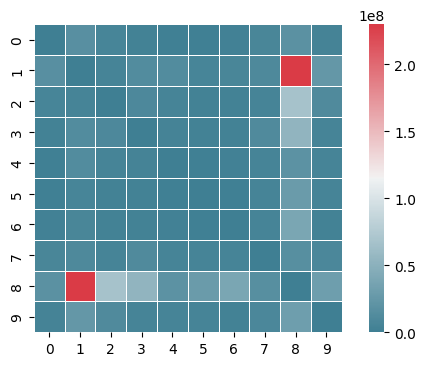

In [23]:
f, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(dtw_matrix,
          cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True, ax=ax, linewidths=.5)
plt.show()

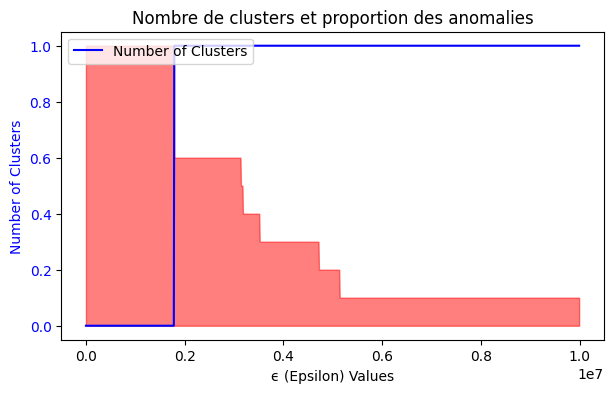

In [24]:
# X est la matrice de similarité
X = dtw_matrix


epsilon_values = np.arange(1, 10000000,10000)

# Initialize lists to store results
num_clusters_list = []
proportion_anomalies_list = []
silhouette_scores = []


for eps_value in epsilon_values:
    # Appliquer DBSCAN
    dbscan = DBSCAN(eps=eps_value, min_samples=4, metric='precomputed')
    dbscan.fit(X)

    # Recevoir les clusters labels
    labels = dbscan.labels_

    # Compter le nombre de cluter
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count the proportion of anomalies (points labeled as -1)
    proportion_anomalies = np.sum(labels == -1) / len(labels)

    # Ajout des résultats dans une liste
    num_clusters_list.append(num_clusters)
    proportion_anomalies_list.append(proportion_anomalies)
    try :
      silhouette_scores.append(silhouette_score(X, labels))
    except :
      pass



fig, ax1 = plt.subplots(figsize=(7, 4))


ax1.plot(epsilon_values, num_clusters_list, label='Number of Clusters', color='blue')
ax1.set_xlabel('ϵ (Epsilon) Values')
ax1.set_ylabel('Number of Clusters', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')


ax1.fill_between(epsilon_values, 0, proportion_anomalies_list, color='red', alpha=0.5, label='Proportion des Anomalies')

plt.title('Nombre de clusters et proportion des anomalies')
plt.show()

In [25]:
average_score = np.mean(silhouette_scores)
average_score

0.5183903535176447

In [26]:
list_comparaison.append(ajout_donnee('DTW',dtw_runtime,average_score))
list_comparaison

[{'mesure de similarité': 'DTW',
  'runtime': 248.9011514186859,
  'avg_sihouette_score': 0.5183903535176447}]

## Frechet Distance  

In [27]:
frechet_matrix = np.zeros((length,length))

In [29]:
start_time = time.time()
i = 0
for uid_1 in df1['uid'].unique() :
  j = 0
  for uid_2 in df1['uid'].unique() :
    trajectory_1 = df1[df1['uid']==uid_1].values[:,1:]
    trajectory_2 = df1[df1['uid']==uid_2].values[:,1:]
    frechet_matrix[i][j] = frechet_dist(trajectory_1,trajectory_2)
    j += 1
  i += 1

end_time = time.time()

In [30]:
# Calcul du temps d'execution
frechet_runtime = end_time - start_time
print(frechet_runtime)

255.63075804710388


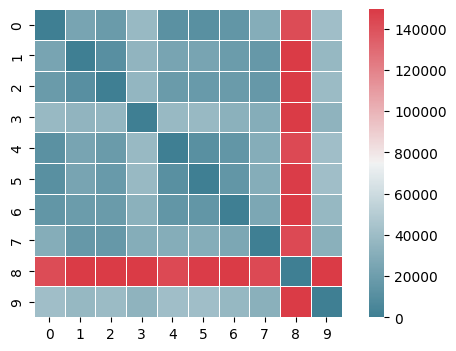

In [31]:
f, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(frechet_matrix,
          cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True, ax=ax, linewidths=.5)
plt.show()

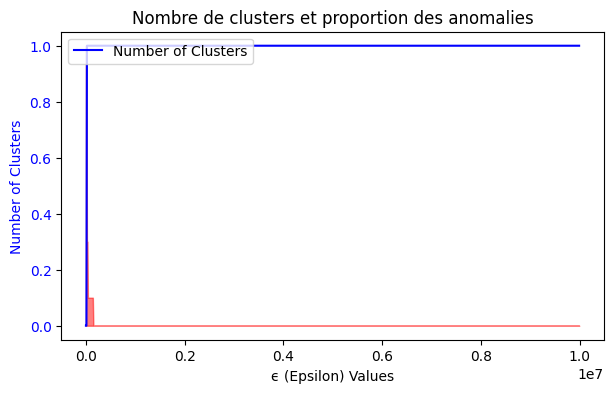

In [32]:
# X est la matrice de similarité
X = frechet_matrix

epsilon_values = np.arange(1, 10000000,10000)

# Initialize lists to store results
num_clusters_list = []
proportion_anomalies_list = []
silhouette_scores = []


for eps_value in epsilon_values:
    # Appliquer DBSCAN
    dbscan = DBSCAN(eps=eps_value, min_samples=4, metric='precomputed')
    dbscan.fit(X)

    # Recevoir les clusters labels
    labels = dbscan.labels_

    # Compter le nombre de cluter
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count the proportion of anomalies (points labeled as -1)
    proportion_anomalies = np.sum(labels == -1) / len(labels)

    # Ajout des résultats dans une liste
    num_clusters_list.append(num_clusters)
    proportion_anomalies_list.append(proportion_anomalies)
    try :
      silhouette_scores.append(silhouette_score(X, labels))
    except :
      pass



fig, ax1 = plt.subplots(figsize=(7, 4))


ax1.plot(epsilon_values, num_clusters_list, label='Number of Clusters', color='blue')
ax1.set_xlabel('ϵ (Epsilon) Values')
ax1.set_ylabel('Number of Clusters', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')


ax1.fill_between(epsilon_values, 0, proportion_anomalies_list, color='red', alpha=0.5, label='Proportion des Anomalies')

plt.title('Nombre de clusters et proportion des anomalies')
plt.show()

In [33]:
average_score = np.mean(silhouette_scores)
average_score

0.7373681692231192

In [36]:
list_comparaison.append(ajout_donnee('Frechet Distance',frechet_runtime,average_score))
list_comparaison

[{'mesure de similarité': 'DTW',
  'runtime': 248.9011514186859,
  'avg_sihouette_score': 0.5183903535176447},
 {'mesure de similarité': 'Frechet Distance',
  'runtime': 255.63075804710388,
  'avg_sihouette_score': 0.7373681692231192}]

## Manhattan Distance

In [37]:
manhattan_matrix = np.zeros((length,length))

In [38]:
start_time = time.time()
i = 0
for uid_1 in df1['uid'].unique() :
  j = 0
  for uid_2 in df1['uid'].unique() :
    trajectory_1 = df1[df1['uid']==uid_1].values[:,1:]
    trajectory_2 = df1[df1['uid']==uid_2].values[:,1:]
    manhattan_matrix[i][j] = hausdorff_distance(trajectory_1,trajectory_2,distance="manhattan")
    j += 1
  i += 1

end_time = time.time()


In [41]:
manhattan_runtime = end_time - start_time
manhattan_runtime

11.02030348777771

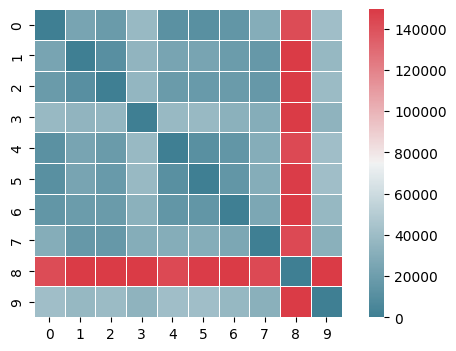

In [42]:
f, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(manhattan_matrix,
          cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True, ax=ax, linewidths=.5)
plt.show()

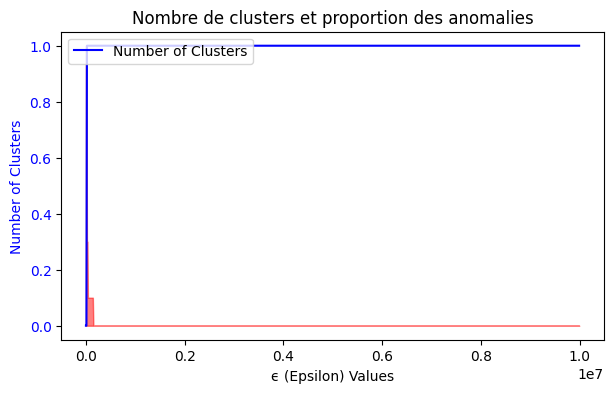

In [43]:
# X est la matrice de similarité
X = manhattan_matrix

epsilon_values = np.arange(1, 10000000,10000)

# Initializer les listes pour stocker les données
num_clusters_list = []
proportion_anomalies_list = []
silhouette_scores = []


for eps_value in epsilon_values:
    # Appliquer DBSCAN
    dbscan = DBSCAN(eps=eps_value, min_samples=4, metric='precomputed')
    dbscan.fit(X)

    # Recevoir les clusters labels
    labels = dbscan.labels_

    # Compter le nombre de cluter
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count the proportion of anomalies (points labeled as -1)
    proportion_anomalies = np.sum(labels == -1) / len(labels)

    # Ajout des résultats dans une liste
    num_clusters_list.append(num_clusters)
    proportion_anomalies_list.append(proportion_anomalies)
    try :
      silhouette_scores.append(silhouette_score(X, labels))
    except :
      pass



fig, ax1 = plt.subplots(figsize=(7, 4))


ax1.plot(epsilon_values, num_clusters_list, label='Number of Clusters', color='blue')
ax1.set_xlabel('ϵ (Epsilon) Values')
ax1.set_ylabel('Number of Clusters', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')


ax1.fill_between(epsilon_values, 0, proportion_anomalies_list, color='red', alpha=0.5, label='Proportion des Anomalies')

plt.title('Nombre de clusters et proportion des anomalies')
plt.show()

In [44]:
average_score = np.mean(silhouette_scores)
average_score

0.7373671405075075

In [45]:
list_comparaison.append(ajout_donnee('Hausdorff Manhattan Distance',manhattan_runtime,average_score))
list_comparaison

[{'mesure de similarité': 'DTW',
  'runtime': 248.9011514186859,
  'avg_sihouette_score': 0.5183903535176447},
 {'mesure de similarité': 'Frechet Distance',
  'runtime': 255.63075804710388,
  'avg_sihouette_score': 0.7373681692231192},
 {'mesure de similarité': 'Hausdorff Manhattan Distance',
  'runtime': 11.02030348777771,
  'avg_sihouette_score': 0.7373671405075075}]

## Chebyshev Distance  

In [61]:
chebyshev_matrix = np.zeros((length,length))

In [62]:
start_time = time.time()
i = 0
for uid_1 in df1['uid'].unique() :
  j = 0
  for uid_2 in df1['uid'].unique() :
    trajectory_1 = df1[df1['uid']==uid_1].values[:,1:]
    trajectory_2 = df1[df1['uid']==uid_2].values[:,1:]
    chebyshev_matrix[i][j] = hausdorff_distance(trajectory_1,trajectory_2,distance="euclidean")
    j += 1
  i += 1

end_time = time.time()

In [63]:
chebyshev_runtime = end_time - start_time
chebyshev_runtime

9.748305082321167

In [64]:
chebyshev_matrix

array([[     0.        ,  24302.00000183,  18187.00000151,
         37742.00000043,  11674.00000025,  11548.00000007,
         14649.00000057,  30032.00000001, 141905.00000027,
         40934.00000338],
       [ 24302.00000183,      0.        ,  10976.0000002 ,
         34650.00000011,  24482.00000265,  24386.00000084,
         19011.00000447,  16890.00000273, 149350.00000021,
         36977.00000769],
       [ 18187.00000151,  10976.0000002 ,      0.        ,
         35588.00000151,  18181.00000252,  18083.00000036,
         18157.00000332,  16378.00000175, 149241.00000014,
         38712.00000635],
       [ 37742.00000043,  34650.00000011,  35588.00000151,
             0.        ,  37713.00000016,  37757.00000085,
         32604.00000096,  30164.00000069, 148925.00000014,
         34258.00000681],
       [ 11674.00000025,  24482.00000265,  18181.00000252,
         37713.00000016,      0.        ,  11525.00000023,
         14830.00000067,  30205.00000006, 143169.00000021,
         40

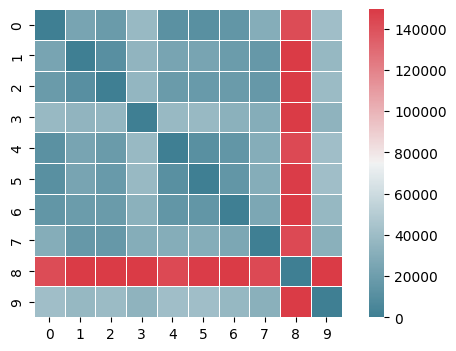

In [65]:
f, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(chebyshev_matrix,
          cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True, ax=ax, linewidths=.5)
plt.show()

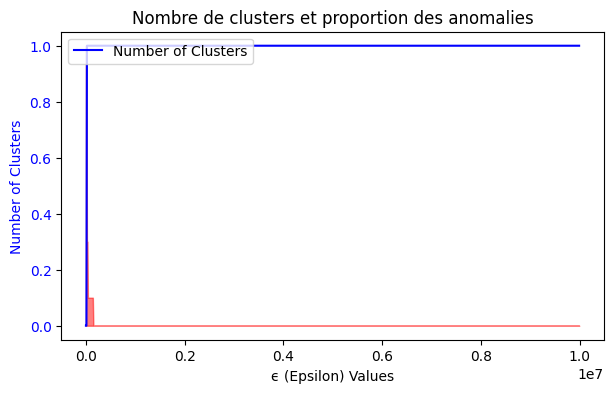

In [66]:
# X est la matrice de similarité
X = chebyshev_matrix

epsilon_values = np.arange(1, 10000000,10000)

# Initializer les listes pour stocker les données
num_clusters_list = []
proportion_anomalies_list = []
silhouette_scores = []


for eps_value in epsilon_values:
    # Appliquer DBSCAN
    dbscan = DBSCAN(eps=eps_value, min_samples=4, metric='precomputed')
    dbscan.fit(X)

    # Recevoir les clusters labels
    labels = dbscan.labels_

    # Compter le nombre de cluter
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count the proportion of anomalies (points labeled as -1)
    proportion_anomalies = np.sum(labels == -1) / len(labels)

    # Ajout des résultats dans une liste
    num_clusters_list.append(num_clusters)
    proportion_anomalies_list.append(proportion_anomalies)
    try :
      silhouette_scores.append(silhouette_score(X, labels))
    except :
      pass



fig, ax1 = plt.subplots(figsize=(7, 4))


ax1.plot(epsilon_values, num_clusters_list, label='Number of Clusters', color='blue')
ax1.set_xlabel('ϵ (Epsilon) Values')
ax1.set_ylabel('Number of Clusters', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')


ax1.fill_between(epsilon_values, 0, proportion_anomalies_list, color='red', alpha=0.5, label='Proportion des Anomalies')

plt.title('Nombre de clusters et proportion des anomalies')
plt.show()

In [67]:
average_score = np.mean(silhouette_scores)
average_score

0.7373681692231192

In [68]:
list_comparaison.append(ajout_donnee('Hausdorff Chebyshev Distance',chebyshev_runtime,average_score))
list_comparaison

[{'mesure de similarité': 'DTW',
  'runtime': 248.9011514186859,
  'avg_sihouette_score': 0.5183903535176447},
 {'mesure de similarité': 'Frechet Distance',
  'runtime': 255.63075804710388,
  'avg_sihouette_score': 0.7373681692231192},
 {'mesure de similarité': 'Hausdorff Manhattan Distance',
  'runtime': 11.02030348777771,
  'avg_sihouette_score': 0.7373671405075075},
 {'mesure de similarité': 'Hausdorff Chebyshev Distance',
  'runtime': 9.748305082321167,
  'avg_sihouette_score': 0.7373681692231192}]

## Euclidean Distance

In [69]:
euclidean_matrix = np.zeros((length,length))
start_time = time.time()
i = 0
for uid_1 in df1['uid'].unique() :
  j = 0
  for uid_2 in df1['uid'].unique() :
    trajectory_1 = df1[df1['uid']==uid_1].values[:,1:]
    trajectory_2 = df1[df1['uid']==uid_2].values[:,1:]
    euclidean_matrix[i][j] = hausdorff_distance(trajectory_1,trajectory_2,distance="euclidean")
    j += 1
  i += 1

end_time = time.time()
euclidean_runtime = end_time - start_time

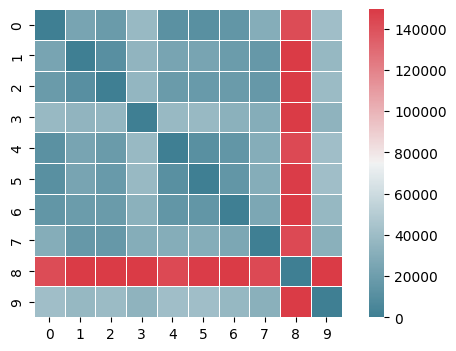

In [71]:
f, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(euclidean_matrix,
          cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True, ax=ax, linewidths=.5)
plt.show()

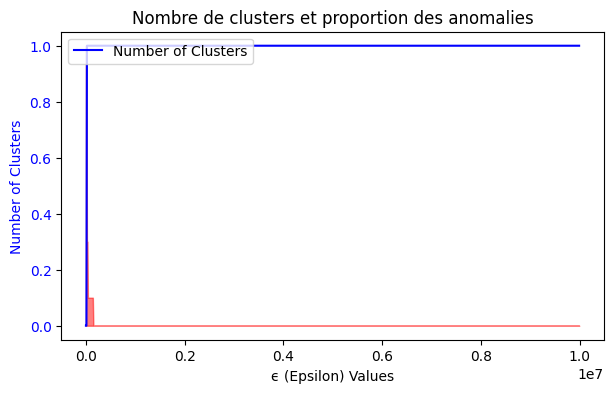

In [72]:
# X est la matrice de similarité
X = euclidean_matrix

epsilon_values = np.arange(1, 10000000,10000)

# Initializer les listes pour stocker les données
num_clusters_list = []
proportion_anomalies_list = []
silhouette_scores = []


for eps_value in epsilon_values:
    # Appliquer DBSCAN
    dbscan = DBSCAN(eps=eps_value, min_samples=4, metric='precomputed')
    dbscan.fit(X)

    # Recevoir les clusters labels
    labels = dbscan.labels_

    # Compter le nombre de cluter
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count the proportion of anomalies (points labeled as -1)
    proportion_anomalies = np.sum(labels == -1) / len(labels)

    # Ajout des résultats dans une liste
    num_clusters_list.append(num_clusters)
    proportion_anomalies_list.append(proportion_anomalies)
    try :
      silhouette_scores.append(silhouette_score(X, labels))
    except :
      pass



fig, ax1 = plt.subplots(figsize=(7, 4))


ax1.plot(epsilon_values, num_clusters_list, label='Number of Clusters', color='blue')
ax1.set_xlabel('ϵ (Epsilon) Values')
ax1.set_ylabel('Number of Clusters', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')


ax1.fill_between(epsilon_values, 0, proportion_anomalies_list, color='red', alpha=0.5, label='Proportion des Anomalies')

plt.title('Nombre de clusters et proportion des anomalies')
plt.show()

In [73]:
average_score = np.mean(silhouette_scores)
list_comparaison.append(ajout_donnee('Hausdorff Euclidean Distance',euclidean_runtime,average_score))
euclidean_runtime

10.074520826339722

In [74]:
list_comparaison

[{'mesure de similarité': 'DTW',
  'runtime': 248.9011514186859,
  'avg_sihouette_score': 0.5183903535176447},
 {'mesure de similarité': 'Frechet Distance',
  'runtime': 255.63075804710388,
  'avg_sihouette_score': 0.7373681692231192},
 {'mesure de similarité': 'Hausdorff Manhattan Distance',
  'runtime': 11.02030348777771,
  'avg_sihouette_score': 0.7373671405075075},
 {'mesure de similarité': 'Hausdorff Chebyshev Distance',
  'runtime': 9.748305082321167,
  'avg_sihouette_score': 0.7373681692231192},
 {'mesure de similarité': 'Hausdorff Euclidean Distance',
  'runtime': 10.074520826339722,
  'avg_sihouette_score': 0.7373681692231192}]

## PCM

In [76]:
pcm_matrix = np.zeros((length,length))

In [78]:
pcm_matrix = np.zeros((length,length))
start_time = time.time()
i = 0
for uid_1 in df1['uid'].unique() :
  j = 0
  for uid_2 in df1['uid'].unique() :
    trajectory_1 = df1[df1['uid']==uid_1].values[:,1:]
    trajectory_2 = df1[df1['uid']==uid_2].values[:,1:]
    pcm_matrix[i][j] = pcm(trajectory_1,trajectory_2,)
    j += 1
  i += 1

end_time = time.time()
pcm_runtime = end_time - start_time

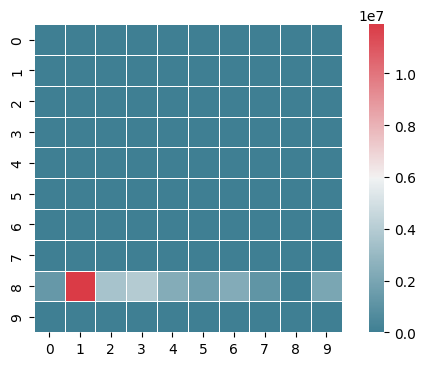

In [79]:
f, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pcm_matrix,
          cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True, ax=ax, linewidths=.5)
plt.show()

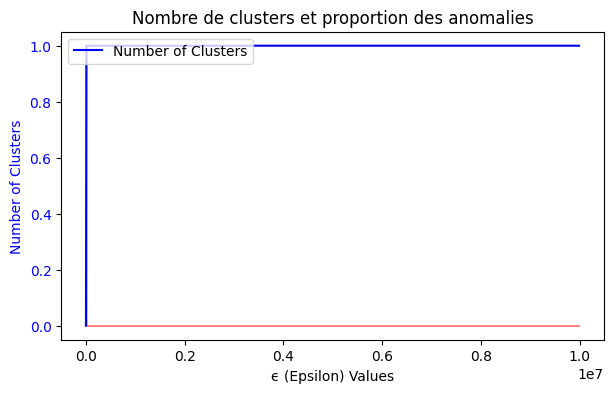

In [80]:
# X est la matrice de similarité
X = pcm_matrix

epsilon_values = np.arange(1, 10000000,10000)

# Initializer les listes pour stocker les données
num_clusters_list = []
proportion_anomalies_list = []
silhouette_scores = []


for eps_value in epsilon_values:
    # Appliquer DBSCAN
    dbscan = DBSCAN(eps=eps_value, min_samples=4, metric='precomputed')
    dbscan.fit(X)

    # Recevoir les clusters labels
    labels = dbscan.labels_

    # Compter le nombre de cluter
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count the proportion of anomalies (points labeled as -1)
    proportion_anomalies = np.sum(labels == -1) / len(labels)

    # Ajout des résultats dans une liste
    num_clusters_list.append(num_clusters)
    proportion_anomalies_list.append(proportion_anomalies)
    try :
      silhouette_scores.append(silhouette_score(X, labels))
    except :
      pass



fig, ax1 = plt.subplots(figsize=(7, 4))


ax1.plot(epsilon_values, num_clusters_list, label='Number of Clusters', color='blue')
ax1.set_xlabel('ϵ (Epsilon) Values')
ax1.set_ylabel('Number of Clusters', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')


ax1.fill_between(epsilon_values, 0, proportion_anomalies_list, color='red', alpha=0.5, label='Proportion des Anomalies')

plt.title('Nombre de clusters et proportion des anomalies')
plt.show()

In [81]:
average_score = np.mean(silhouette_scores)
list_comparaison.append(ajout_donnee('PCM',pcm_runtime,average_score))

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [82]:
comparaison = pd.DataFrame(list_comparaison)
comparaison

,mesure de similarité,runtime,avg_sihouette_score
0,DTW,248.901151,0.518390
1,Frechet Distance,255.630758,0.737368
2,Hausdorff Manhattan Distance,11.020303,0.737367
3,Hausdorff Chebyshev Distance,9.748305,0.737368
4,Hausdorff Euclidean Distance,10.074521,0.737368
5,PCM,11.532627,NaN
